# Mini Project 2

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score

In [22]:
df = pd.read_csv('insurance-2.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## Requirement 1 "Understand our customers first" (EDA) 
Before you build anything, show me what drives medical costs. Which customer attributes matter most? Are there any surprising patterns? I want visuals I can show to the board. Deliverable: An exploratory data analysis with at least 5 meaningful visualizations and a short-written summary of insights (effect of smoking, BMI, age on charges). Handle any data cleaning/encoding needed. 

Luckily for us, the dataset already appears clean, what is left to be done is categorizing the non numeric data and normalizing the numerical data

In [23]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
feature_cols = numeric_features + categorical_features
target_col = ['charges']

X = df[feature_cols]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

In [24]:
results = {}
pipes = {}
for col in feature_cols:
    if col in numeric_features:
        pre = StandardScaler()
    else:
        pre = OneHotEncoder()

    pipe = make_pipeline(pre, LinearRegression())
    pipe.fit(X_train[[col]], y_train)
    y_pred = pipe.predict(X_test[[col]])
    pipes[col] = pipe

    results[col] = {
        'r2' : r2_score(y_test, y_pred),
        'rmse': root_mean_squared_error(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T.sort_values('r2', ascending=False)
display(results_df)

,r2,rmse,mae
smoker,0.617377,7296.560128,5395.152670
bmi,0.043995,11533.538511,9055.705722
age,0.012829,11720.027468,9263.018844
children,0.005921,11760.960604,8883.261663
region,0.002555,11780.857130,8843.383830
sex,0.000740,11791.569459,8850.691996


The results clearly show that whether or not someone is a smoker is the biggest predictor of the charge for someone's insurance. Whether or not a person is a smoker explains 62% of the variance in the charges they face. A person's sex had the least effect on how their plan was priced, likely due to anti-discrimination laws.

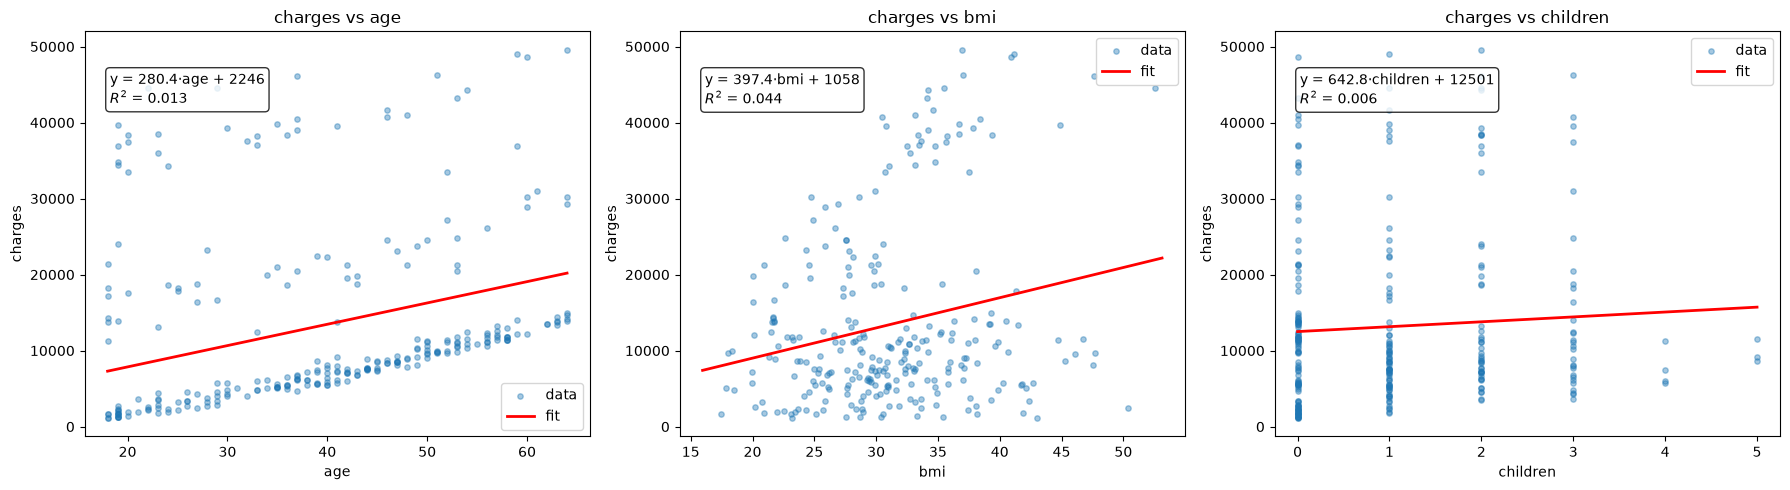

In [27]:
fig, axes = plt.subplots(1, len(numeric_features), figsize=(6 * len(numeric_features), 5))

for ax, col in zip(axes, numeric_features):
    pipe = pipes[col]
    scaler = pipe.named_steps['standardscaler']
    lr     = pipe.named_steps['linearregression']

    # unscale: y = b0 + b1*(x - mean)/std  ->  slope/intercept in original x units
    slope     = lr.coef_[0] / scaler.scale_[0]
    intercept = lr.intercept_ - lr.coef_[0] * scaler.mean_[0] / scaler.scale_[0]

    # data points (use full data or X_test — your choice)
    ax.scatter(X_test[col], y_test, alpha=0.4, s=15, label='data')

    # regression line over the x range
    x_line = np.linspace(X[col].min(), X[col].max(), 100)
    y_line = intercept + slope * x_line
    ax.plot(x_line, y_line, color='red', lw=2, label='fit')

    ax.set_title(f'charges vs {col}')
    ax.set_xlabel(col); ax.set_ylabel('charges')
    ax.annotate(f'y = {slope:.1f}·{col} + {intercept:.0f}\n$R^2$ = {results[col]["r2"]:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction',
                fontsize=10, va='top',
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    ax.legend()

plt.savefig('req1_numerical_plots.png')
plt.tight_layout()
plt.show()


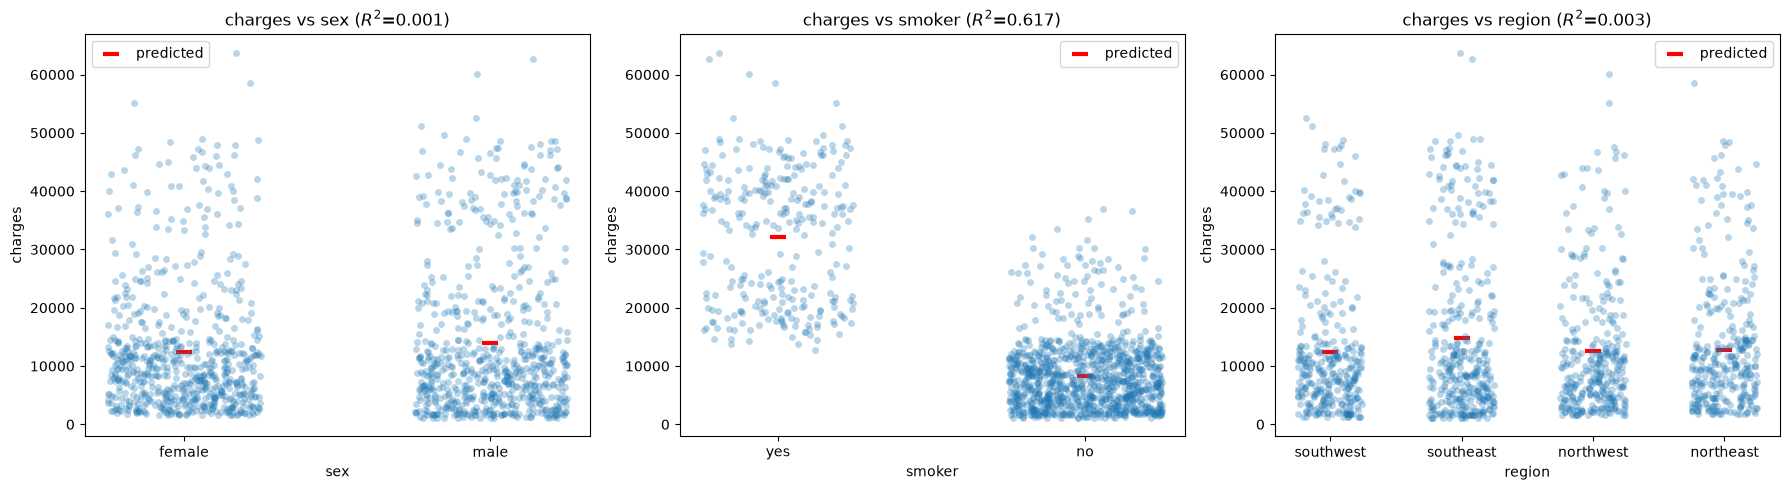

In [28]:
fig, axes = plt.subplots(1, len(categorical_features), figsize=(6 * len(categorical_features), 5))

for ax, col in zip(axes, categorical_features):
    pipe = pipes[col]
    seaborn.stripplot(x=df[col], y=df['charges'], ax=ax, alpha=0.3, jitter=0.25)

    # model prediction for each category
    cats = df[col].unique()
    preds = pipe.predict(pd.DataFrame({col: cats}))
    ax.scatter(range(len(cats)), preds, color='red', s=120, marker='_', lw=3, label='predicted')

    ax.set_title(f'charges vs {col} ($R^2$={results[col]["r2"]:.3f})')
    ax.legend()

plt.savefig('req1_categorical_plots.png')
plt.tight_layout()
plt.show()


## Requirement 2 "Predict the medical charges" (Regression) 
I need a tool that estimates how much a new customer will cost us per year, so we can price their premium 
fairly. 
Deliverable: Build, compare, and evaluate the following regression models to predict charges: 
### Model Notes 
1. Simple Linear Regression Use the single best predictor you found in EDA 
2. Multiple Linear Regression All features  
3. Polynomial Regression Try degrees 2–4; discuss overfitting 
4. Ridge Regression (L2) Tune alpha 
5. Lasso Regression (L1) Tune alpha; report which features it eliminated 
6. Support  Vector  Regression (SVR) Try at least two kernels; remember to scale features 
7. Decision Tree Regression Control max_depth; visualize the tree if possible 
 
Evaluation: Use a proper train/test split. Compare all models with MAE, MSE, RMSE, and R² in a single 
summary table, and recommend ONE model to the stakeholder with justification. 